In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import cv2
import numpy as np

In [ ]:
import os

def collect_left_cc_image_paths(root_path):
    """
    Collect all Left CC image paths
    """
    left_cc_paths = []

    # Traverse all directories
    for category in os.listdir(root_path):
        category_dir = os.path.join(root_path, category)
        if not os.path.isdir(category_dir):
            continue

        for patient_id in os.listdir(category_dir):
            patient_dir = os.path.join(category_dir, patient_id)
            if not os.path.isdir(patient_dir):
                continue

            for fname in os.listdir(patient_dir):
                # Skip non-image files
                if ("Mask" in fname) or ("OVERLAY" in fname) or fname.endswith(".ics"):
                    continue

                # Check whether the file is an image and contains LEFT and CC
                if fname.lower().endswith((".jpg", ".png", ".jpeg")):
                    fname_upper = fname.upper()
                    if 'LEFT' in fname_upper and 'CC' in fname_upper:
                        fpath = os.path.join(patient_dir, fname)
                        left_cc_paths.append(fpath)

    return left_cc_paths

# Example usage
if __name__ == "__main__":
    root_path = '/content/drive/MyDrive/DDSM/DDSM_unzipped'

    # Collect all Left CC image paths
    left_cc_paths = collect_left_cc_image_paths(root_path)

    # Print the results
    print(f"Found {len(left_cc_paths)} Left CC images")
    print("\nFirst 10 image paths:")
    for i, path in enumerate(left_cc_paths[:10], 1):
        print(f"{i:2d}. {path}")


找到 1976 张Left CC图像

前10张图像路径:
 1. /content/drive/MyDrive/DDSM/DDSM_unzipped/Benign/0029/C_0029_1.LEFT_CC.jpg
 2. /content/drive/MyDrive/DDSM/DDSM_unzipped/Benign/0033/C_0033_1.LEFT_CC.jpg
 3. /content/drive/MyDrive/DDSM/DDSM_unzipped/Benign/0217/C_0217_1.LEFT_CC.jpg
 4. /content/drive/MyDrive/DDSM/DDSM_unzipped/Benign/0234/C_0234_1.LEFT_CC.jpg
 5. /content/drive/MyDrive/DDSM/DDSM_unzipped/Benign/0235/C_0235_1.LEFT_CC.jpg
 6. /content/drive/MyDrive/DDSM/DDSM_unzipped/Benign/0236/C_0236_1.LEFT_CC.jpg
 7. /content/drive/MyDrive/DDSM/DDSM_unzipped/Benign/0237/C_0237_1.LEFT_CC.jpg
 8. /content/drive/MyDrive/DDSM/DDSM_unzipped/Benign/0238/C_0238_1.LEFT_CC.jpg
 9. /content/drive/MyDrive/DDSM/DDSM_unzipped/Benign/0239/C_0239_1.LEFT_CC.jpg
10. /content/drive/MyDrive/DDSM/DDSM_unzipped/Benign/0240/C_0240_1.LEFT_CC.jpg


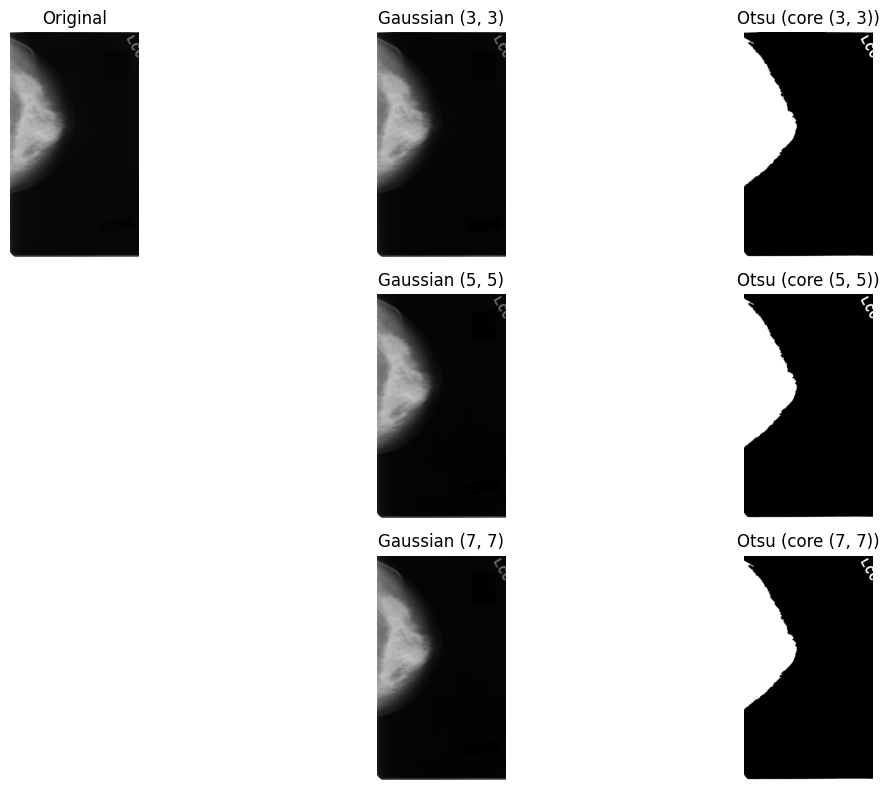

In [ ]:
import cv2
import matplotlib.pyplot as plt

# 1. Load the grayscale image
img = cv2.imread("/content/drive/MyDrive/DDSM/DDSM_unzipped/Benign/0029/C_0029_1.LEFT_CC.jpg", cv2.IMREAD_GRAYSCALE)

# 2. Define different kernel sizes
kernels = [(3,3), (5,5), (7,7)]
results = []

for k in kernels:
    # Gaussian blur
    blur = cv2.GaussianBlur(img, k, 0)
    # Otsu thresholding
    _, otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    results.append((k, blur, otsu))

# 3. Visualize the comparison
plt.figure(figsize=(12,8))

# Original image
plt.subplot(3,3,1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

# Results for different kernel sizes
for i, (k, blur, otsu) in enumerate(results):
    # Show the blurred image
    plt.subplot(3,3,2 + 3*i)
    plt.imshow(blur, cmap="gray")
    plt.title(f"Gaussian {k}")
    plt.axis("off")

    # Show the Otsu-thresholded image
    plt.subplot(3,3,3 + 3*i)
    plt.imshow(otsu, cmap="gray")
    plt.title(f"Otsu (kernel {k})")
    plt.axis("off")

plt.tight_layout()
plt.show()


核 (3, 3): Otsu阈值=77.00, 前景比例=0.167
核 (5, 5): Otsu阈值=77.00, 前景比例=0.166
核 (7, 7): Otsu阈值=77.00, 前景比例=0.166


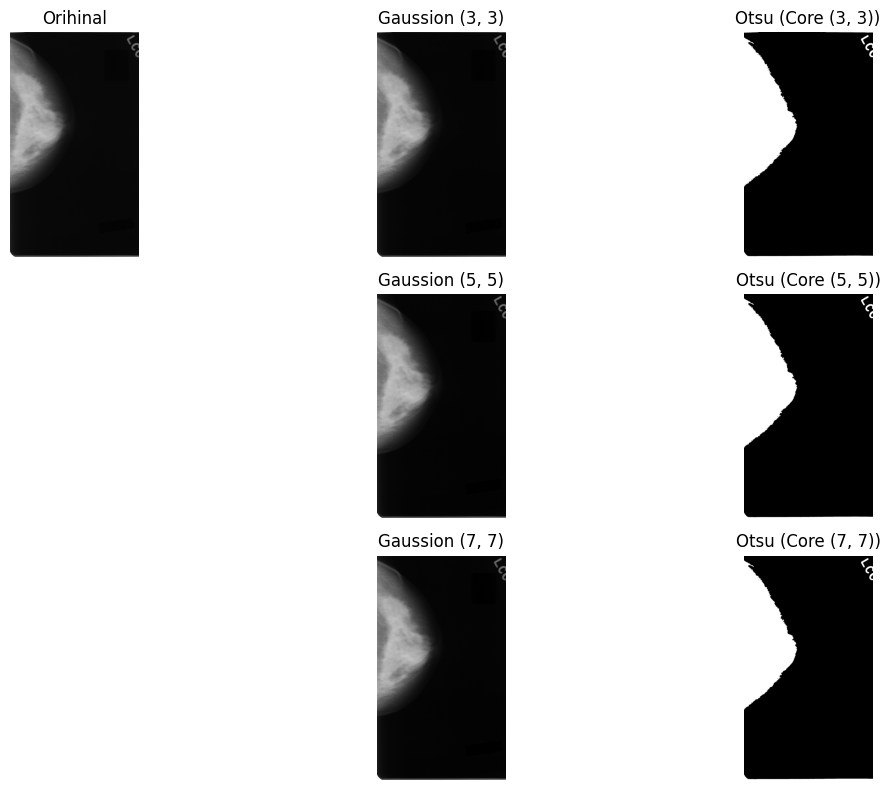

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the grayscale image
img = cv2.imread("/content/drive/MyDrive/DDSM/DDSM_unzipped/Benign/0029/C_0029_1.LEFT_CC.jpg", cv2.IMREAD_GRAYSCALE)

kernels = [(3,3), (5,5), (7,7)]
results = []

for k in kernels:
    # Gaussian blur
    blur = cv2.GaussianBlur(img, k, 0)
    # Otsu thresholding
    thresh_val, otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)  # tune parameter

    # Foreground ratio
    foreground_ratio = np.sum(otsu == 255) / otsu.size

    results.append((k, blur, otsu, thresh_val, foreground_ratio))

    print(f"Kernel {k}: Otsu threshold={thresh_val:.2f}, foreground ratio={foreground_ratio:.3f}")

# 2. Visualize the comparison
plt.figure(figsize=(12,8))
plt.subplot(3,3,1)
plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off")

for i, (k, blur, otsu, _, _) in enumerate(results):
    plt.subplot(3,3,2 + 3*i)
    plt.imshow(blur, cmap="gray")
    plt.title(f"Gaussian {k}"); plt.axis("off")

    plt.subplot(3,3,3 + 3*i)
    plt.imshow(otsu, cmap="gray")
    plt.title(f"Otsu (kernel {k})"); plt.axis("off")

plt.tight_layout()
plt.show()


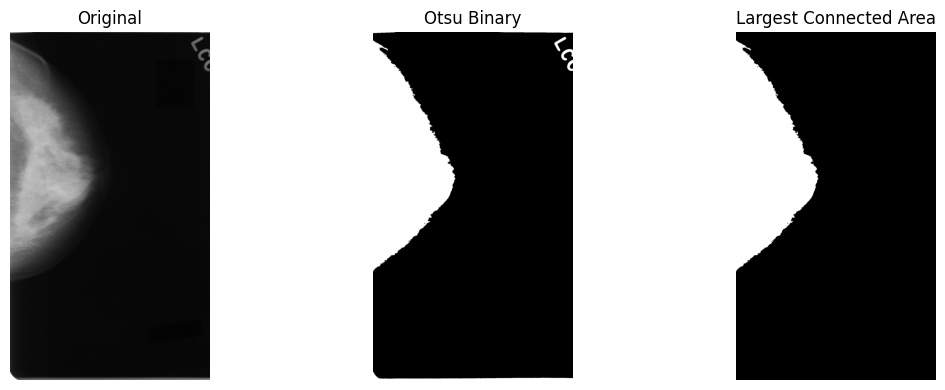

In [ ]:
# 2. Gaussian blur + Otsu thresholding
blur = cv2.GaussianBlur(img, (5,5), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
# 3. Find connected components
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

# 4. Find the largest region (excluding background label=0)
areas = stats[1:, cv2.CC_STAT_AREA]   # Area of each foreground region
max_idx = 1 + np.argmax(areas)        # Label index of the largest region

# 5. Build a mask that keeps only the largest region
mask = np.zeros_like(binary, dtype=np.uint8)
mask[labels == max_idx] = 255

# 6. Visualization
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(binary, cmap="gray"); plt.title("Otsu Binary"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(mask, cmap="gray"); plt.title("Largest Connected Component"); plt.axis("off")
plt.tight_layout()
plt.show()

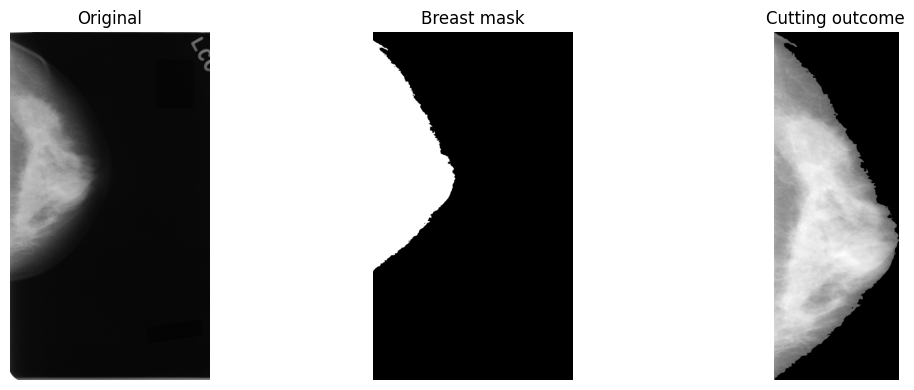

True

In [ ]:
# 5. Find the bounding box of the breast region
ys, xs = np.where(mask > 0)   # Coordinates of the breast region
x0, x1 = xs.min(), xs.max()
y0, y1 = ys.min(), ys.max()

# 6. Crop the breast area using the mask
masked_img = cv2.bitwise_and(img, img, mask=mask)
cropped = masked_img[y0:y1+1, x0:x1+1]

# 7. Visualize the result
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask, cmap="gray"); plt.title("Breast mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(cropped, cmap="gray"); plt.title("Cropped result"); plt.axis("off")
plt.tight_layout()
plt.show()

# 8. Save the result
cv2.imwrite("cropped_breast.png", cropped)

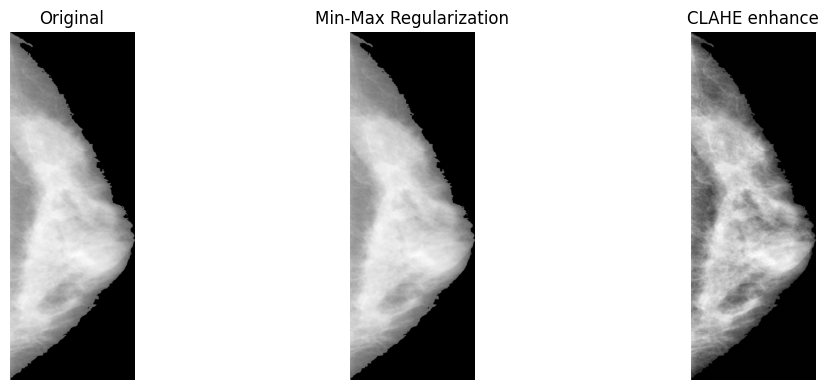

True

In [ ]:
img = cv2.imread("cropped_breast.png", cv2.IMREAD_GRAYSCALE)

# 2. Min-max normalize to [0, 255]
min_val, max_val = img.min(), img.max()
minmax_norm = ((img - min_val) / (max_val - min_val) * 255).astype(np.uint8)

# 3. CLAHE (contrast-limited adaptive histogram equalization)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_img = clahe.apply(img)

# 4. Visualize the comparison
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(minmax_norm, cmap="gray"); plt.title("Min-Max Normalization"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(clahe_img, cmap="gray"); plt.title("CLAHE enhancement"); plt.axis("off")
plt.tight_layout()
plt.show()

# 5. Save the result
cv2.imwrite("minmax_normalized.png", minmax_norm)
cv2.imwrite("clahe_enhanced.png", clahe_img)

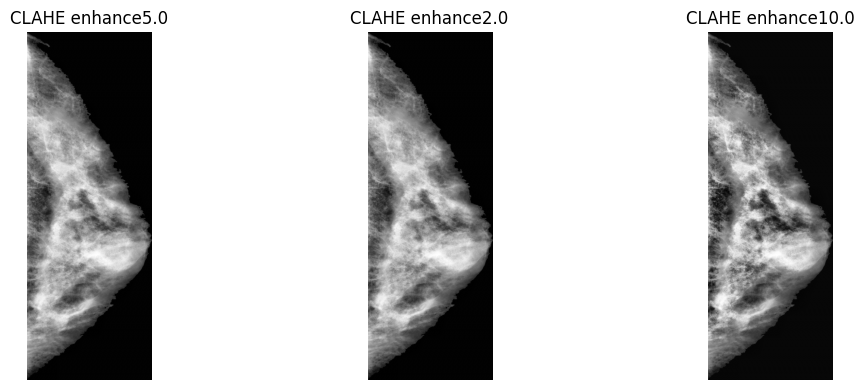

True

In [ ]:
img = cv2.imread("cropped_breast.png", cv2.IMREAD_GRAYSCALE)

# 2. Min-max normalize to [0, 255]
min_val, max_val = img.min(), img.max()
minmax_norm = ((img - min_val) / (max_val - min_val) * 255).astype(np.uint8)

# 3. CLAHE (contrast-limited adaptive histogram equalization)
clahe1 = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8,8))
clahe_img1 = clahe1.apply(img)

clahe12 = cv2.createCLAHE(clipLimit=10.0, tileGridSize=(8,8))
clahe_img2 = clahe12.apply(img)
# 4. Visualize the comparison
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(clahe_img, cmap="gray"); plt.title("CLAHE enhancement5.0"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(clahe_img1, cmap="gray"); plt.title("CLAHE enhancement2.0"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(clahe_img2, cmap="gray"); plt.title("CLAHE enhancement10.0"); plt.axis("off")
plt.tight_layout()
plt.show()

# 5. Save the result
cv2.imwrite("clahe_enhanced2.png", clahe_img2)
cv2.imwrite("clahe_enhanced1.png", clahe_img1)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def process_mammogram(image_path, output_dir=None, clip_limit=2.0, visualize=True):
    """
    End-to-end processing function for mammogram images

    Args:
    - image_path: input image path
    - output_dir: output directory (if None, results are not saved)
    - clip_limit: CLAHE clip limit parameter
    - visualize: whether to display the visualizations

    Returns:
    - processed_data: dictionary containing all processing outputs
    """

    # Create the output directory
    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(exist_ok=True)

    # Store all processing outputs
    results = {}

    # 1. Read the original image
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: unable to read image {image_path}")
        return None

    results['original'] = img
    image_name = Path(image_path).stem

    if visualize:
        plt.figure(figsize=(15, 10))

    # 2. Gaussian blur + Otsu thresholding
    blur = cv2.GaussianBlur(img, (5, 5), 0)
    _, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    results['binary'] = binary

    if visualize:
        plt.subplot(2, 3, 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Original\n{img.shape}")
        plt.axis("off")

        plt.subplot(2, 3, 2)
        plt.imshow(binary, cmap="gray")
        plt.title("Otsu Binary")
        plt.axis("off")

    # 3. Find connected components
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

    # 4. Find the largest region (excluding background label=0)
    if num_labels > 1:
        areas = stats[1:, cv2.CC_STAT_AREA]
        max_idx = 1 + np.argmax(areas)

        # 5. Build a mask that keeps only the largest region
        mask = np.zeros_like(binary, dtype=np.uint8)
        mask[labels == max_idx] = 255
        results['mask'] = mask

        # 6. Find the breast-region bounding box and crop it
        ys, xs = np.where(mask > 0)
        x0, x1 = xs.min(), xs.max()
        y0, y1 = ys.min(), ys.max()

        masked_img = cv2.bitwise_and(img, img, mask=mask)
        cropped = masked_img[y0:y1+1, x0:x1+1]
        results['cropped'] = cropped
        results['bbox'] = (x0, y0, x1, y1)

        if visualize:
            plt.subplot(2, 3, 3)
            plt.imshow(mask, cmap="gray")
            plt.title(f"Breast Mask\nArea: {areas.max()}px")
            plt.axis("off")

            plt.subplot(2, 3, 4)
            plt.imshow(cropped, cmap="gray")
            plt.title(f"Cropped Breast\n{cropped.shape}")
            plt.axis("off")

        # Save the cropped result
        if output_dir:
            cv2.imwrite(str(output_dir / f"{image_name}_cropped.png"), cropped)
    else:
        print(f"Warning: no connected component found in {image_path}")
        return results

    # 7. Apply enhancement to the cropped image
    # Min-max normalization
    min_val, max_val = cropped.min(), cropped.max()
    minmax_norm = ((cropped - min_val) / (max_val - min_val) * 255).astype(np.uint8)
    results['minmax_norm'] = minmax_norm

    # CLAHE enhancement
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(8, 8))
    clahe_img = clahe.apply(cropped)
    results['clahe_enhanced'] = clahe_img

    if visualize:
        plt.subplot(2, 3, 5)
        plt.imshow(minmax_norm, cmap="gray")
        plt.title("Min-Max Normalization")
        plt.axis("off")

        plt.subplot(2, 3, 6)
        plt.imshow(clahe_img, cmap="gray")
        plt.title(f"CLAHE (clipLimit={clip_limit})")
        plt.axis("off")

        plt.suptitle(f"Processing Results - {image_name}", fontsize=16)
        plt.tight_layout()
        plt.show()

    # Save the enhanced results
    if output_dir:
        cv2.imwrite(str(output_dir / f"{image_name}_minmax_norm.png"), minmax_norm)
        cv2.imwrite(str(output_dir / f"{image_name}_clahe_cl{clip_limit}.png"), clahe_img)

    return results

def compare_clahe_parameters(image_path, clip_limits=[2.0, 5.0, 10.0], output_dir=None):
    """
    Compare the effect of different CLAHE parameters

    Args:
    - image_path: input image path
    - clip_limits: list of CLAHE clip limits to compare
    - output_dir: output directory
    """

    # Run the base processing first to obtain the cropped image
    base_results = process_mammogram(image_path, visualize=False)
    if base_results is None or 'cropped' not in base_results:
        return

    cropped_img = base_results['cropped']
    image_name = Path(image_path).stem

    plt.figure(figsize=(15, 5))

    # Display the original cropped image
    plt.subplot(1, len(clip_limits) + 1, 1)
    plt.imshow(cropped_img, cmap="gray")
    plt.title("Original Cropped")
    plt.axis("off")

    # Apply CLAHE with different parameter settings
    clahe_results = {}
    for i, clip_limit in enumerate(clip_limits):
        clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=(8, 8))
        clahe_img = clahe.apply(cropped_img)
        clahe_results[clip_limit] = clahe_img

        plt.subplot(1, len(clip_limits) + 1, i + 2)
        plt.imshow(clahe_img, cmap="gray")
        plt.title(f"CLAHE clipLimit={clip_limit}")
        plt.axis("off")

        # Save the result
        if output_dir:
            output_dir = Path(output_dir)
            output_dir.mkdir(exist_ok=True)
            cv2.imwrite(str(output_dir / f"{image_name}_clahe_cl{clip_limit}.png"), clahe_img)

    plt.suptitle(f"CLAHE Parameter Comparison - {image_name}", fontsize=16)
    plt.tight_layout()
    plt.show()

    return clahe_results

def batch_process_images(input_dir, output_dir, clip_limit=2.0):
    """
    Batch-process all images in a directory

    Args:
    - input_dir: input image directory
    - output_dir: output directory
    - clip_limit: CLAHE clip limit parameter
    """

    input_path = Path(input_dir)
    output_path = Path(output_dir)
    output_path.mkdir(exist_ok=True)

    image_extensions = ['.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp']
    image_files = [f for f in input_path.iterdir() if f.suffix.lower() in image_extensions]

    print(f"Found {len(image_files)} images to process...")

    all_results = {}
    for image_file in image_files:
        print(f"Processing: {image_file.name}")
        results = process_mammogram(
            str(image_file),
            output_dir=output_dir,
            clip_limit=clip_limit,
            visualize=False  # Do not display plots during batch processing
        )

        if results:
            all_results[image_file.name] = results

    print("Batch processing complete!")
    return all_results

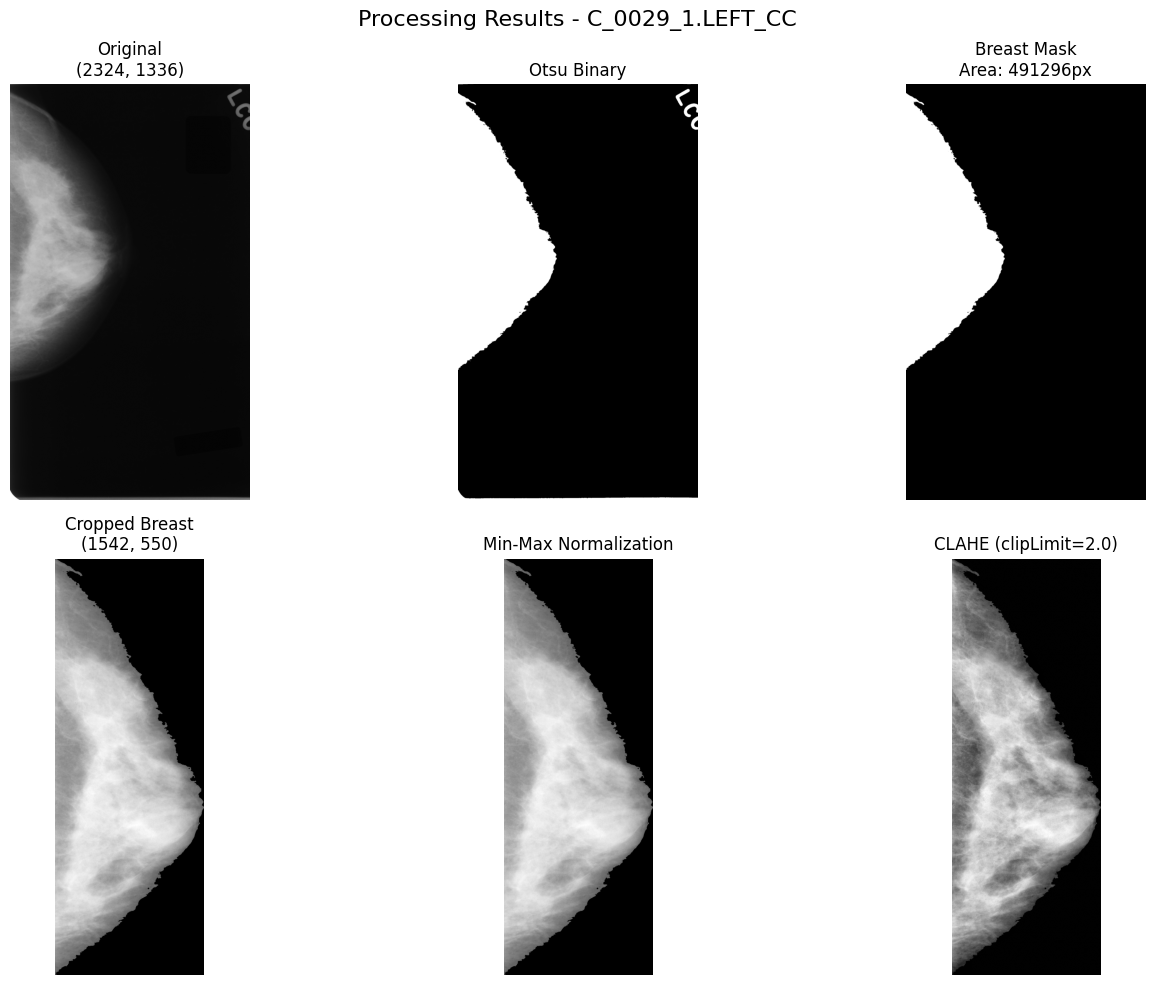

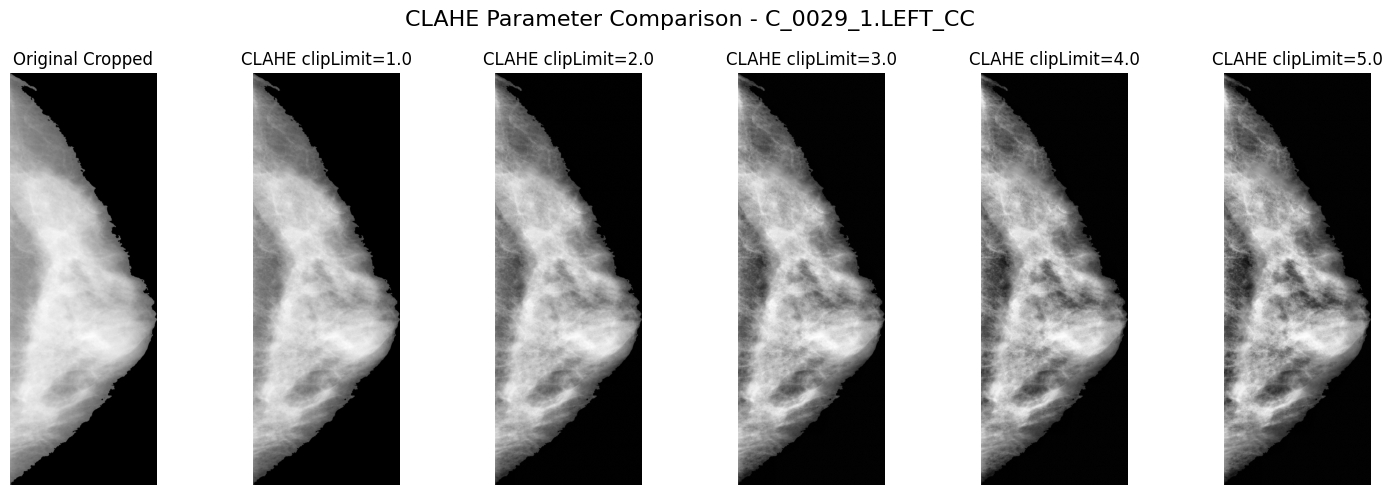

{1.0: array([[66, 66,  2, ...,  2,  2,  2],
        [69, 67, 66, ...,  2,  2,  2],
        [71, 67, 66, ...,  2,  2,  2],
        ...,
        [61, 58, 54, ...,  2,  2,  2],
        [59, 56, 53, ...,  2,  2,  2],
        [56, 53,  2, ...,  2,  2,  2]], dtype=uint8),
 2.0: array([[52, 52,  3, ...,  3,  3,  3],
        [57, 55, 52, ...,  3,  3,  3],
        [60, 55, 52, ...,  3,  3,  3],
        ...,
        [45, 40, 36, ...,  3,  3,  3],
        [43, 38, 33, ...,  3,  3,  3],
        [38, 33,  2, ...,  3,  3,  3]], dtype=uint8),
 3.0: array([[39, 39,  3, ...,  4,  4,  4],
        [46, 43, 39, ...,  4,  4,  4],
        [49, 43, 39, ...,  4,  4,  4],
        ...,
        [38, 31, 25, ...,  4,  4,  4],
        [35, 28, 23, ...,  4,  4,  4],
        [28, 23,  3, ...,  4,  4,  4]], dtype=uint8),
 4.0: array([[29, 29,  4, ...,  5,  5,  5],
        [37, 33, 29, ...,  5,  5,  5],
        [41, 33, 29, ...,  5,  5,  5],
        ...,
        [35, 29, 22, ...,  5,  5,  5],
        [32, 25, 20, ...,

In [ ]:
results = process_mammogram("/content/drive/MyDrive/DDSM/DDSM_unzipped/Benign/0033/C_0033_1.LEFT_CC.jpg", output_dir="results", clip_limit=2.0, visualize=True)

# Compare different parameter settings
compare_clahe_parameters("/content/drive/MyDrive/DDSM/DDSM_unzipped/Benign/0033/C_0033_1.LEFT_CC.jpg", clip_limits=[1.0, 2.0, 3.0, 4.0, 5.0])

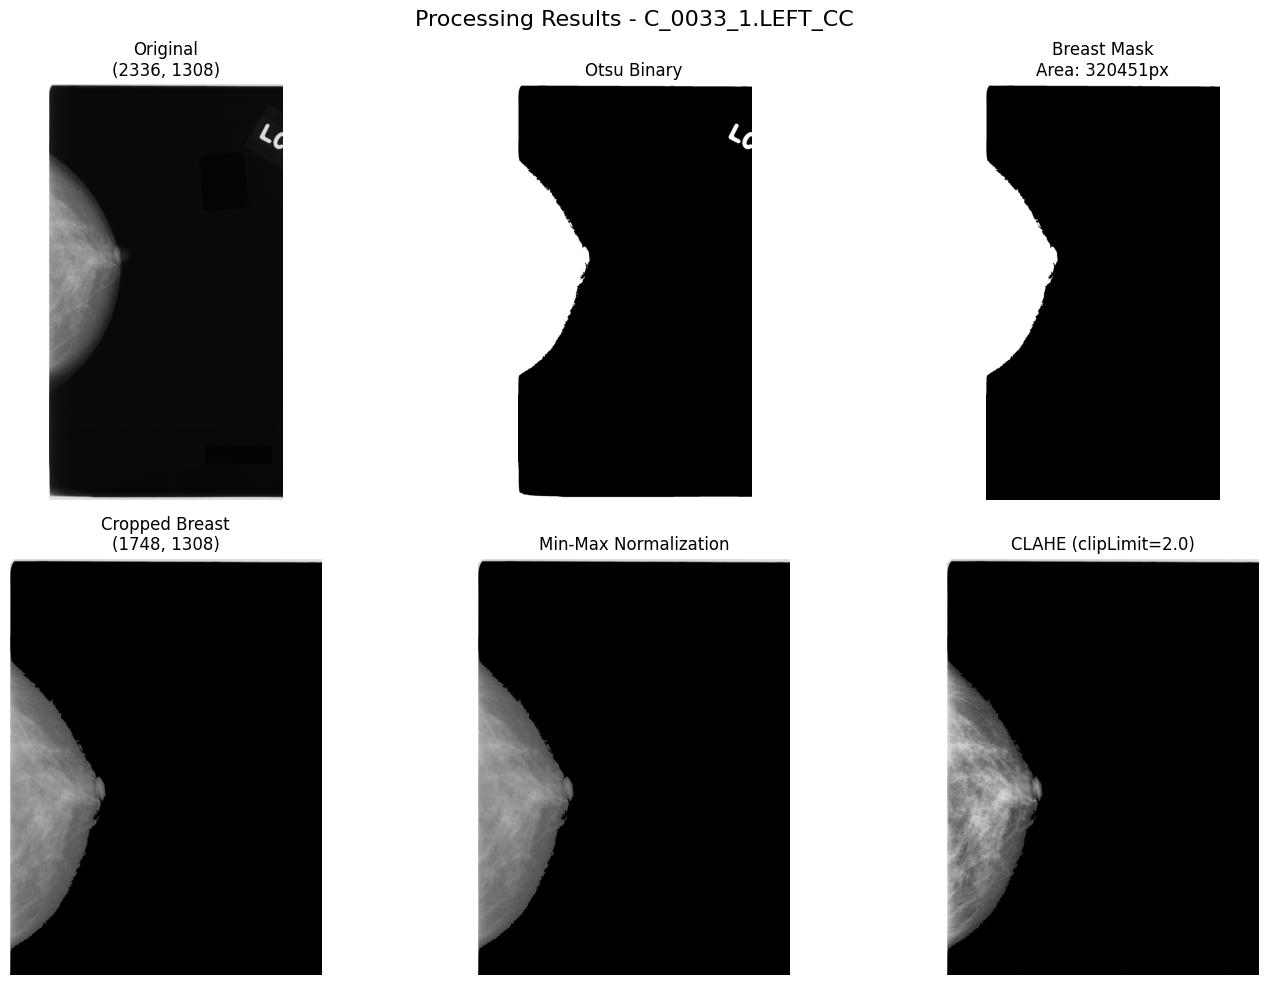

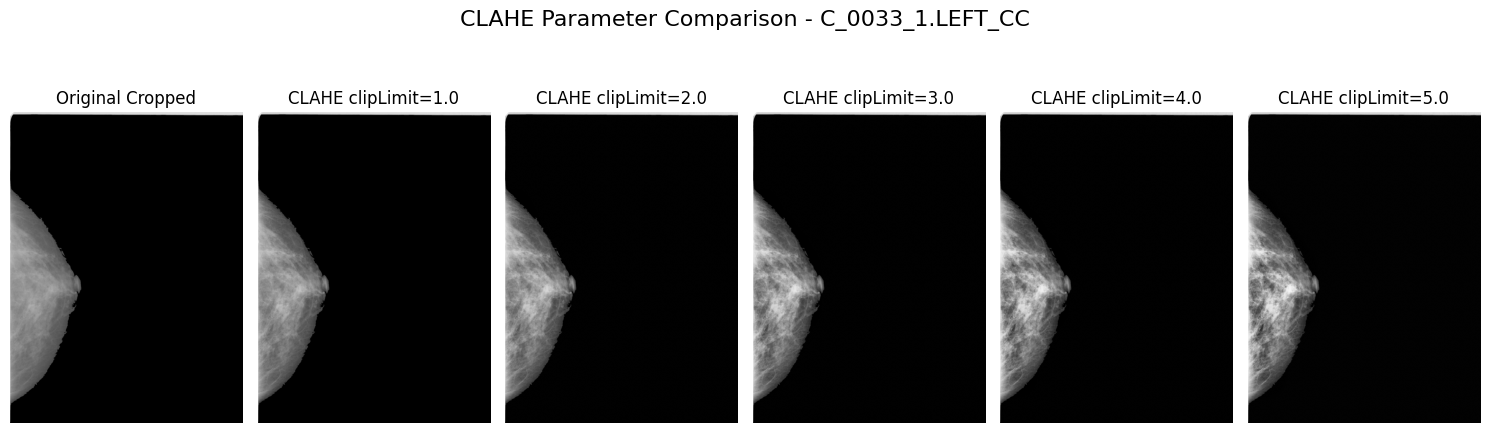

{1.0: array([[255, 255, 255, ..., 226, 226, 224],
        [255, 255, 255, ..., 226, 226, 224],
        [255, 255, 255, ..., 226, 224, 224],
        ...,
        [144,   2,   2, ...,   2,   2,   2],
        [143,   2,   2, ...,   2,   2,   2],
        [141,   2,   2, ...,   2,   2,   2]], dtype=uint8),
 2.0: array([[255, 255, 255, ..., 227, 227, 224],
        [255, 255, 255, ..., 227, 227, 224],
        [255, 255, 255, ..., 227, 224, 224],
        ...,
        [148,   3,   3, ...,   3,   3,   3],
        [146,   3,   3, ...,   3,   3,   3],
        [145,   3,   3, ...,   3,   3,   3]], dtype=uint8),
 3.0: array([[255, 255, 255, ..., 227, 227, 224],
        [255, 255, 255, ..., 227, 227, 224],
        [255, 255, 255, ..., 227, 224, 224],
        ...,
        [148,   4,   4, ...,   4,   4,   4],
        [147,   4,   4, ...,   4,   4,   4],
        [145,   4,   4, ...,   4,   4,   4]], dtype=uint8),
 4.0: array([[255, 255, 255, ..., 228, 228, 224],
        [255, 255, 255, ..., 228, 228, 22